# Data Exploration

End-to-end view of the **processed** PD and LGD datasets that drive the
TabPFNCredit benchmark. Everything below operates on the cached
TALENT-format arrays under `data/processed/<task>/<dataset>/` (`N.npy`,
`C.npy`, `y.npy`, `info.json`). Raw CSV / parquet files are not used
here -- if a dataset is missing from `data/processed/`, the first cell
below auto-preprocesses it from `data/raw/` before anything else runs.

Every figure is saved as PDF under `figures/data_exploration/` *and*
rendered inline below its cell. Re-running the notebook starts from a
clean `figures/data_exploration/` directory.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
from IPython.display import display

from src.data.dataset_inventory import list_datasets
from src.data.preprocessing import preprocess_dataset
from src.visualizations.experiment_plots import apply_style, reset_figure_dir
from src.visualizations.data_exploration import (
    list_processed_datasets,
    processed_dataset_summary_table,
    pd_target_balance_table,
    lgd_target_distribution_table,
    numeric_feature_stats,
    plot_dataset_size_bar,
    plot_target_balance,
    plot_lgd_target_hists,
    plot_correlation_heatmap,
    plot_pca_2d,
)

apply_style()

FIGURES_DIR = PROJECT_ROOT / 'figures' / 'data_exploration'
FIGURES_DIR = reset_figure_dir(FIGURES_DIR)
print(f'Figures will be saved to: {FIGURES_DIR}')

Figures will be saved to: c:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\figures\data_exploration


## 1. Auto-preprocess any missing dataset

Walk every dataset that exists in `data/raw/{pd,lgd}/` and make sure its
processed counterpart is on disk. Already-preprocessed datasets are a
no-op so re-running this cell is cheap.

In [2]:
def ensure_preprocessed(task: str) -> list:
    """Preprocess any dataset of `task` not yet cached. Returns the list of
    dataset names that ended up successfully cached."""
    successes = []
    for dataset in list_datasets(task):
        proc_dir = PROJECT_ROOT / 'data' / 'processed' / task / dataset
        if (proc_dir / 'y.npy').exists():
            successes.append(dataset)
            continue
        try:
            preprocess_dataset(task, dataset)
            successes.append(dataset)
            print(f'  [preprocessed] {task}/{dataset}')
        except Exception as exc:
            print(f'  [skip] {task}/{dataset}: {exc}')
    return successes

pd_datasets = ensure_preprocessed('pd')
lgd_datasets = ensure_preprocessed('lgd')

print()
print(f'Processed PD  datasets: {len(pd_datasets)}')
print(f'Processed LGD datasets: {len(lgd_datasets)}')


Processed PD  datasets: 14
Processed LGD datasets: 7


## 2. Processed-dataset summary tables

One row per dataset: row count, number of numeric vs categorical
features, target stats. Built from the on-disk `info.json` plus the
preprocessed arrays.

In [3]:
proc_pd = processed_dataset_summary_table('pd')
display(proc_pd.sort_values('rows', ascending=False))

,dataset,task,rows,n_num_features,n_cat_features,n_total_features,target_mean,target_min,target_max
5,0006.hackerearth,pd,532428,27,8,35,0.236327,0.0,1.0
11,0012.home_credit,pd,307511,104,16,120,0.080729,0.0,1.0
2,0003.vehicle_loan,pd,233154,32,3,35,0.217071,0.0,1.0
13,0014.algorithmwatch,pd,158700,2986,0,2986,0.378091,0.0,1.0
0,0001.gmsc,pd,150000,10,0,10,0.066840,0.0,1.0
10,0011.loan_default,pd,105471,759,0,759,0.092755,0.0,1.0
8,0009.bank_status,pd,100000,16,0,16,0.226390,0.0,1.0
6,0007.cobranded,pd,80000,47,0,47,0.246213,0.0,1.0
1,0002.taiwan_creditcard,pd,30000,23,0,23,0.221200,0.0,1.0
3,0004.lendingclub,pd,9578,12,1,13,0.160054,0.0,1.0


In [4]:
proc_lgd = processed_dataset_summary_table('lgd')
display(proc_lgd.sort_values('rows', ascending=False))

,dataset,task,rows,n_num_features,n_cat_features,n_total_features,target_mean,target_min,target_max
0,0001.heloc,lgd,57931,8,0,8,0.704432,0.00000,1.00000
5,0006.lgd_freddie,lgd,16002,12,8,20,0.458843,0.00000,1.00000
6,0007.lgd_lendingclub,lgd,5627,10,7,17,0.590511,0.00000,1.00000
1,0002.loss2,lgd,4637,29,23,52,0.392032,0.00000,1.00000
2,0003.axa,lgd,2545,2,0,2,0.228130,0.00001,0.99999
3,0004.base_model,lgd,762,114,88,202,0.323387,0.00000,1.00000
4,0005.base_modelisation,lgd,594,179,77,256,0.330075,0.00000,1.00000


In [5]:
proc_all = pd.concat(
    [proc_pd.assign(task='pd'), proc_lgd.assign(task='lgd')], ignore_index=True
)
print('PD + LGD combined:')
if not proc_all.empty:
    display(
        proc_all.groupby('task')[['rows', 'n_num_features', 'n_cat_features', 'n_total_features']]
                .agg(['min', 'median', 'max', 'sum'])
    )

PD + LGD combined:


rows                           n_num_features                     \
      min   median     max      sum            min median   max   sum   
task                                                                    
lgd   594   4637.0   57931    88098              2   12.0   179   354   
pd    999  90000.0  532428  1722026              7   19.5  2986  4052   

     n_cat_features                 n_total_features                     
                min median max  sum              min median   max   sum  
task                                                                     
lgd               0    8.0  88  203                2   20.0   256   557  
pd                0    1.0  16   46                8   21.5  2986  4098

## 3. Dataset sizes (rows per dataset)


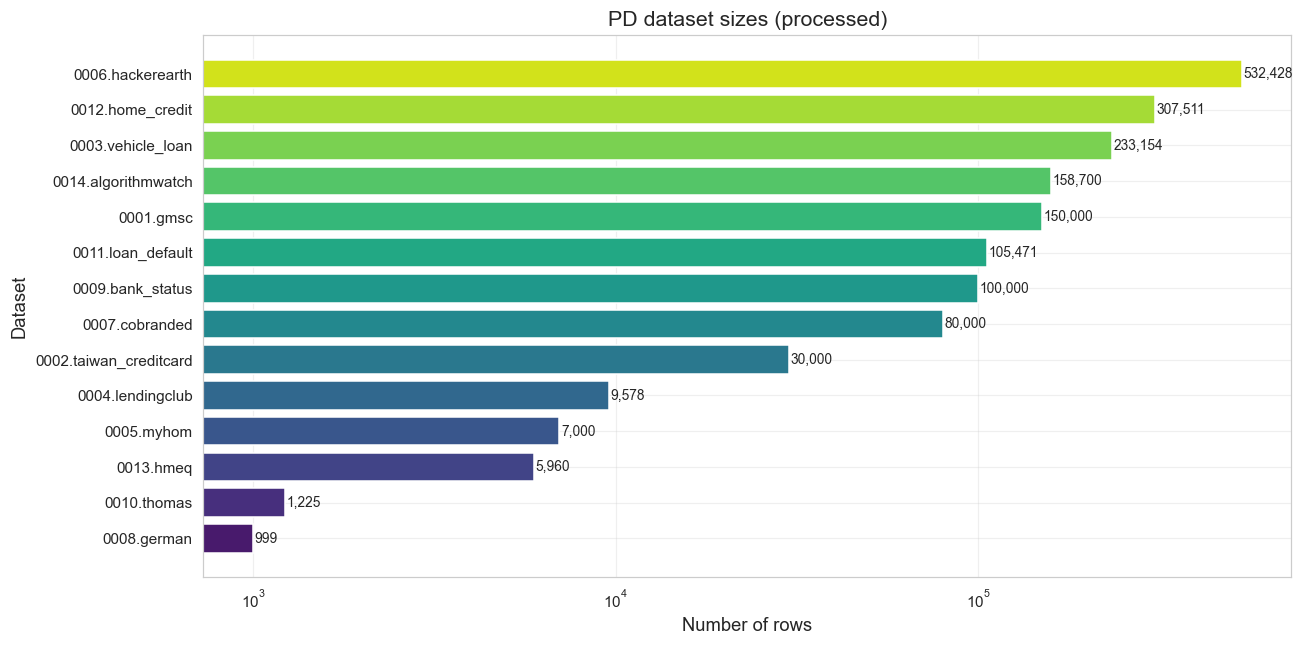

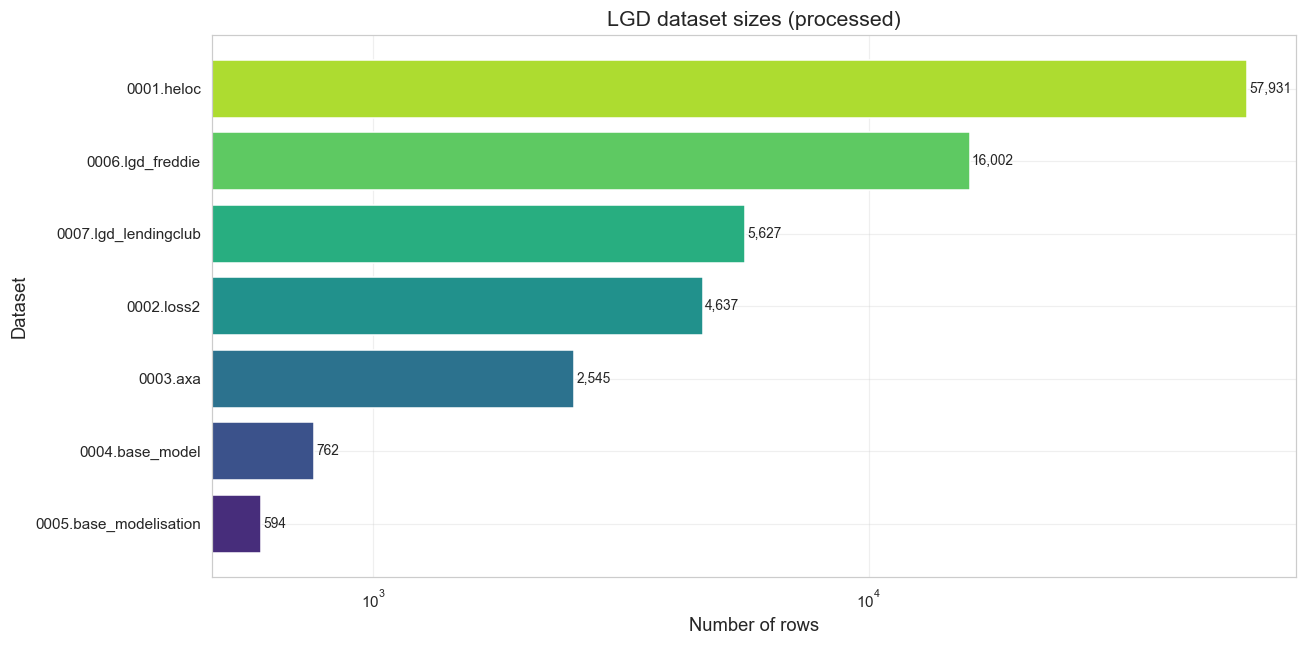

Saved PD + LGD dataset-size charts.


In [6]:
plot_dataset_size_bar('pd',  out_path=FIGURES_DIR / 'pd_dataset_sizes')
plot_dataset_size_bar('lgd', out_path=FIGURES_DIR / 'lgd_dataset_sizes')
print('Saved PD + LGD dataset-size charts.')

## 4. PD class balance

Positive-class rate per PD dataset (sorted ascending). The most
imbalanced datasets here are the ones that drive Experiment 3.

In [7]:
balance = pd_target_balance_table()
display(balance)

,dataset,n_total,n_positive,n_negative,positive_rate,imbalance_ratio
0,0001.gmsc,150000,10026,139974,0.06684,13.96
11,0012.home_credit,307511,24825,282686,0.08073,11.39
10,0011.loan_default,105471,9783,95688,0.09276,9.78
3,0004.lendingclub,9578,1533,8045,0.16005,5.25
12,0013.hmeq,5960,1189,4771,0.19950,4.01
2,0003.vehicle_loan,233154,50611,182543,0.21707,3.61
1,0002.taiwan_creditcard,30000,6636,23364,0.22120,3.52
8,0009.bank_status,100000,22639,77361,0.22639,3.42
5,0006.hackerearth,532428,125827,406601,0.23633,3.23
6,0007.cobranded,80000,19697,60303,0.24621,3.06


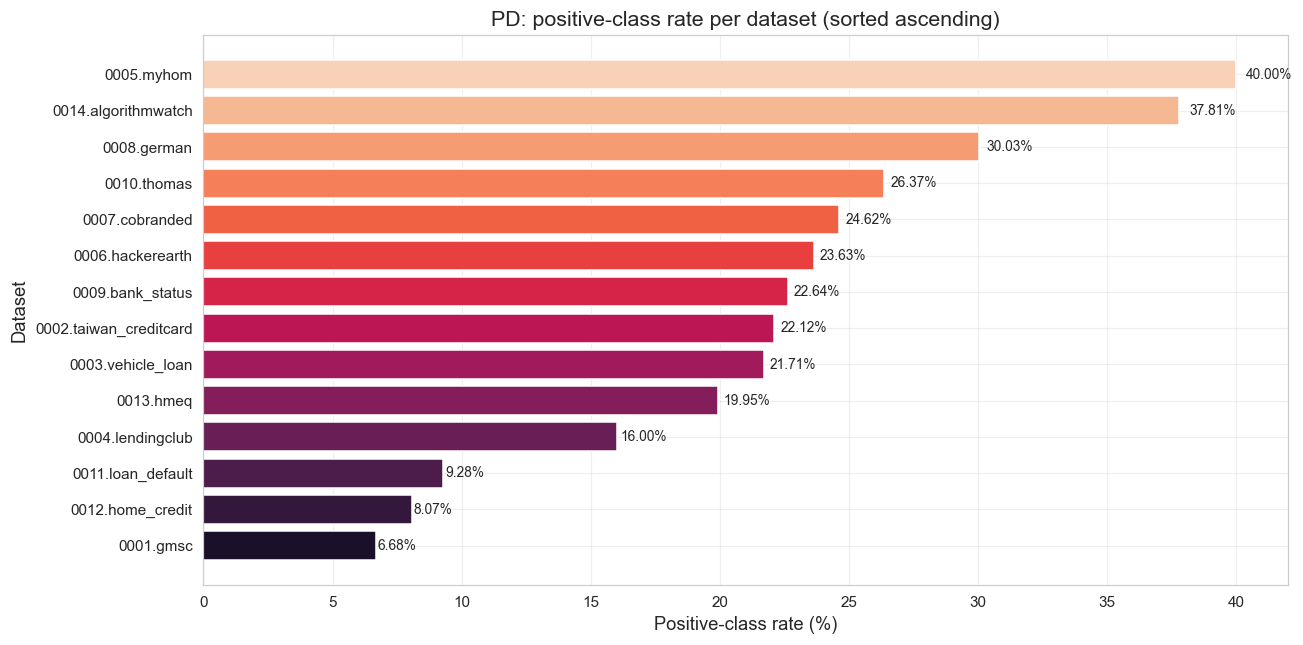

Saved PD class-balance chart.


In [8]:
plot_target_balance(out_path=FIGURES_DIR / 'pd_target_balance')
print('Saved PD class-balance chart.')

## 5. LGD target distribution

Quantiles, skew, zero-rate, and one-rate per LGD dataset. LGD targets
are clipped to `[0, 1]` during preprocessing.

In [9]:
lgd_dist = lgd_target_distribution_table()
display(lgd_dist)

,dataset,n,mean,std,median,skew,q05,q95,pct_zeros,pct_ones
0,0001.heloc,57931,0.7044,0.4170,1.0000,-0.9302,0.0000,1.0000,21.78,51.27
1,0002.loss2,4637,0.3920,0.2714,0.3515,0.5556,0.0326,0.9420,3.62,3.71
2,0003.axa,2545,0.2281,0.3290,0.0321,1.3089,0.0000,1.0000,0.00,0.00
3,0004.base_model,762,0.3234,0.3774,0.1032,0.8270,0.0000,1.0000,10.50,11.94
4,0005.base_modelisation,594,0.3301,0.4094,0.0435,0.7643,0.0000,1.0000,11.62,15.99
5,0006.lgd_freddie,16002,0.4588,0.3182,0.4450,0.1487,0.0000,1.0000,11.42,8.07
6,0007.lgd_lendingclub,5627,0.5905,0.2579,0.6334,-0.4642,0.1233,0.9335,1.48,0.32


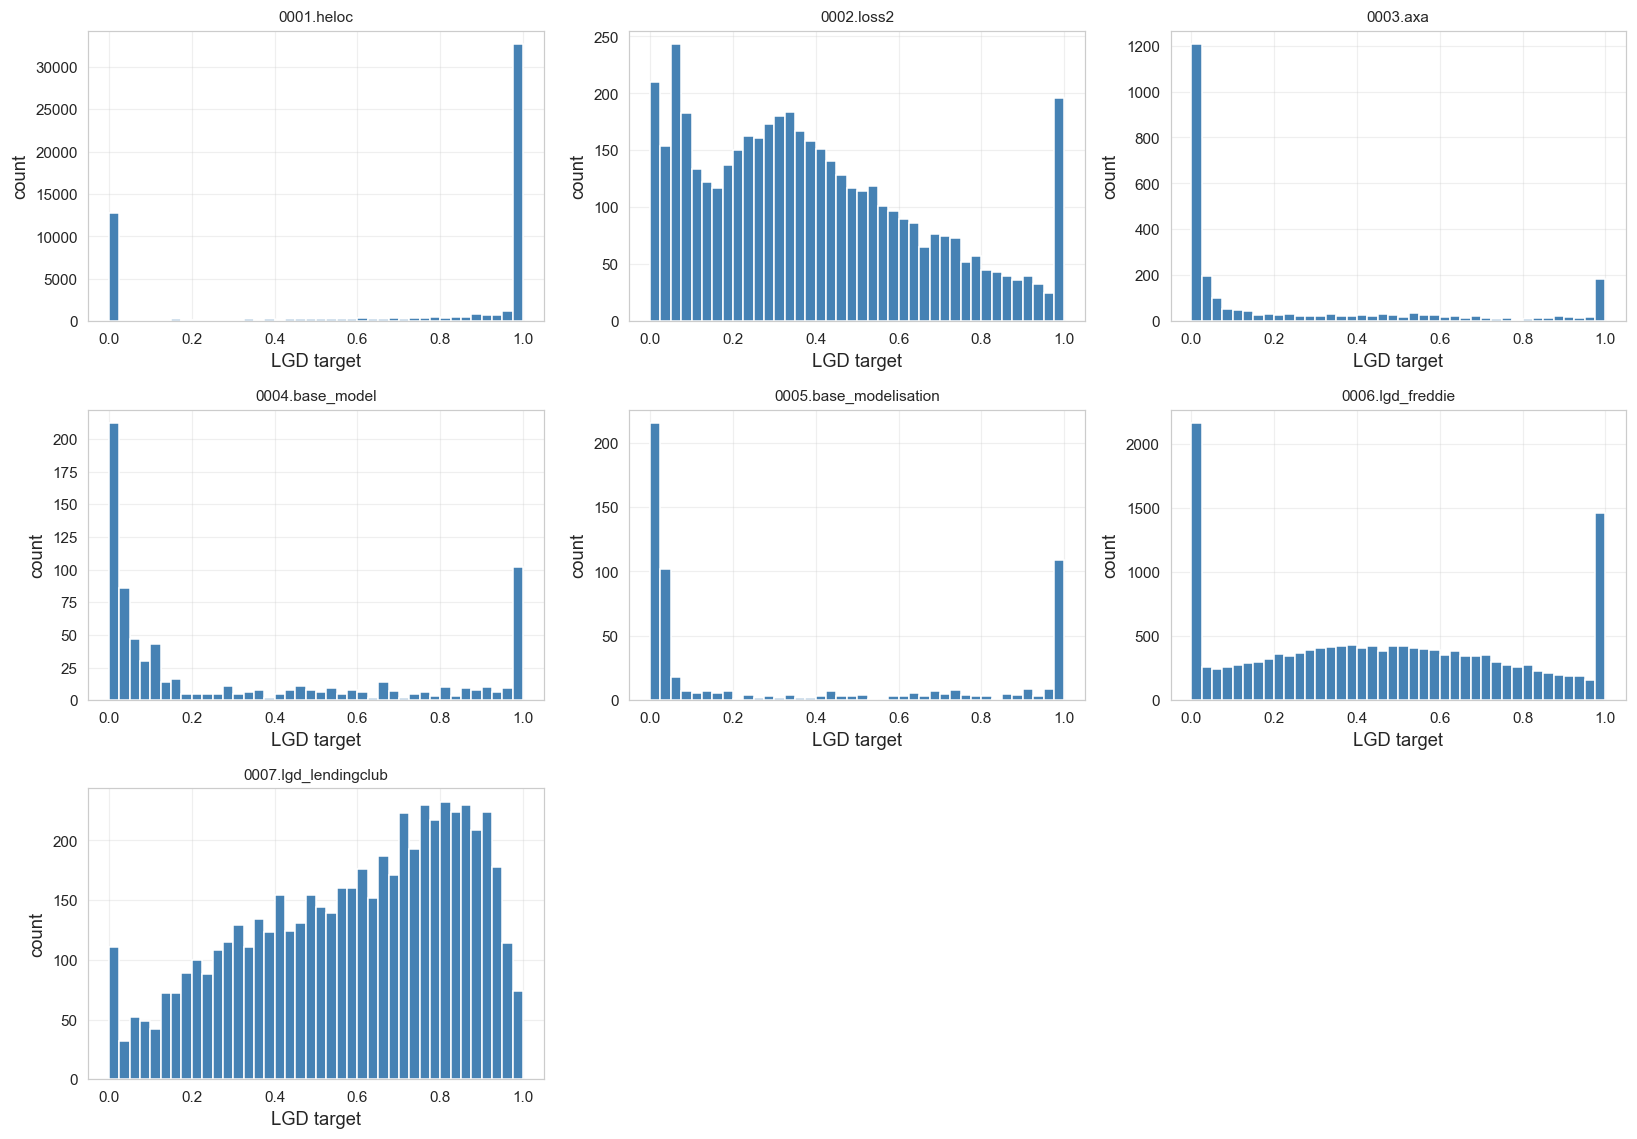

Saved LGD target-histogram grid.


In [10]:
plot_lgd_target_hists(out_path=FIGURES_DIR / 'lgd_target_histograms', ncols=3)
print('Saved LGD target-histogram grid.')

## 6. Per-dataset numeric feature stats

Mean / std / min / max / quartiles for the numerical features of the
largest PD and LGD datasets.

In [11]:
if not proc_pd.empty:
    sample_pd = proc_pd.sort_values('rows', ascending=False).iloc[0]['dataset']
    print(f'Sample PD dataset: {sample_pd}')
    display(numeric_feature_stats('pd', sample_pd).head(20))
else:
    print('No processed PD datasets available.')

Sample PD dataset: 0006.hackerearth


,feature,count,mean,std,min,25%,50%,75%,max,dataset
0,loan_amnt,532428.0,14757.596680,8434.419922,500.00,8000.000000,13000.000000,20000.000000,3.500000e+04,0006.hackerearth
1,funded_amnt,532428.0,14744.272461,8429.139648,500.00,8000.000000,13000.000000,20000.000000,3.500000e+04,0006.hackerearth
2,funded_amnt_inv,532428.0,14704.927734,8441.290039,0.00,8000.000000,13000.000000,20000.000000,3.500000e+04,0006.hackerearth
3,int_rate,532428.0,13.242970,4.379611,5.32,9.990000,12.990000,16.200001,2.899000e+01,0006.hackerearth
4,emp_length,505537.0,6.356933,4.052850,0.00,3.000000,6.000000,11.000000,1.100000e+01,0006.hackerearth
5,annual_inc,532425.0,75029.859375,65199.843750,1200.00,45000.000000,65000.000000,90000.000000,9.500000e+06,0006.hackerearth
6,dti,532428.0,18.138760,8.369074,0.00,11.930000,17.650000,23.950001,6.725200e+02,0006.hackerearth
7,delinq_2yrs,532412.0,0.314448,0.860045,0.00,0.000000,0.000000,0.000000,3.000000e+01,0006.hackerearth
8,inq_last_6mths,532412.0,0.694603,0.997025,0.00,0.000000,0.000000,1.000000,3.100000e+01,0006.hackerearth
9,mths_since_last_delinq,259874.0,34.055737,21.884798,0.00,15.000000,31.000000,50.000000,1.800000e+02,0006.hackerearth


In [12]:
if not proc_lgd.empty:
    sample_lgd = proc_lgd.sort_values('rows', ascending=False).iloc[0]['dataset']
    print(f'Sample LGD dataset: {sample_lgd}')
    display(numeric_feature_stats('lgd', sample_lgd).head(20))
else:
    print('No processed LGD datasets available.')

Sample LGD dataset: 0001.heloc


,feature,count,mean,std,min,25%,50%,75%,max,dataset
0,PortNum,57931.0,1.264073,0.440842,1.0000,1.000000,1.000000,2.000000,2.000000,0001.heloc
1,AvailAmt,57931.0,4.815215,3.675251,0.0000,0.000000,5.519780,7.475141,13.864302,0001.heloc
2,LTV,57931.0,84.321846,32.366779,0.0000,79.899963,94.000000,100.000000,999.899902,0001.heloc
3,LienPos,42633.0,1.810874,0.397617,0.0000,2.000000,2.000000,2.000000,2.000000,0001.heloc
4,Age,57931.0,3.731819,2.578468,1.0000,2.000000,3.000000,5.000000,20.000000,0001.heloc
5,CurrEquifax,55546.0,601.324402,107.894066,360.0000,523.000000,596.000000,685.000000,828.000000,0001.heloc
6,Utilization,57931.0,0.868624,0.292584,0.0000,0.941796,0.992321,1.000000,1.000000,0001.heloc
7,PD_Rnd,57931.0,0.148631,0.216495,0.0003,0.007400,0.031800,0.159300,0.830700,0001.heloc


## 7. Feature-scale overview across all PD datasets

A high `mean_abs_max` or large `features_above_1e4` means the dataset
benefits strongly from per-method normalisation (which TALENT handles
per the method registry).

In [13]:
rows = []
for d in (proc_pd['dataset'] if not proc_pd.empty else []):
    stats = numeric_feature_stats('pd', d)
    if stats.empty:
        continue
    rows.append({
        'dataset': d,
        'n_features': len(stats),
        'mean_abs_max': float(stats['max'].abs().mean()),
        'median_std': float(stats['std'].median()),
        'features_above_1e4': int((stats['max'].abs() > 1e4).sum()),
    })
display(pd.DataFrame(rows))

,dataset,n_features,mean_abs_max,median_std,features_above_1e4
0,0001.gmsc,10,2.846229e+01,1.122429,0
1,0002.taiwan_creditcard,23,4.547240e+05,9.217904,11
2,0003.vehicle_loan,32,6.944917e+07,1.448302,8
3,0004.lendingclub,12,1.636401e+03,2.186782,1
4,0005.myhom,7,6.001101e+05,5.471932,2
5,0006.hackerearth,27,1.138468e+06,23.853437,10
6,0007.cobranded,47,8.026545e+03,2.439688,11
7,0008.german,7,2.655000e+03,1.118802,1
8,0009.bank_status,16,1.149132e+08,6.012597,5
9,0010.thomas,12,2.333625e+04,298.345482,5


## 8. Feature-correlation heatmaps

Pearson correlation between numerical features for the largest PD and
LGD datasets. Bright-red blocks off the diagonal flag near-redundant
features that the post-split PCA step in `data_feeder.py` cleans up.

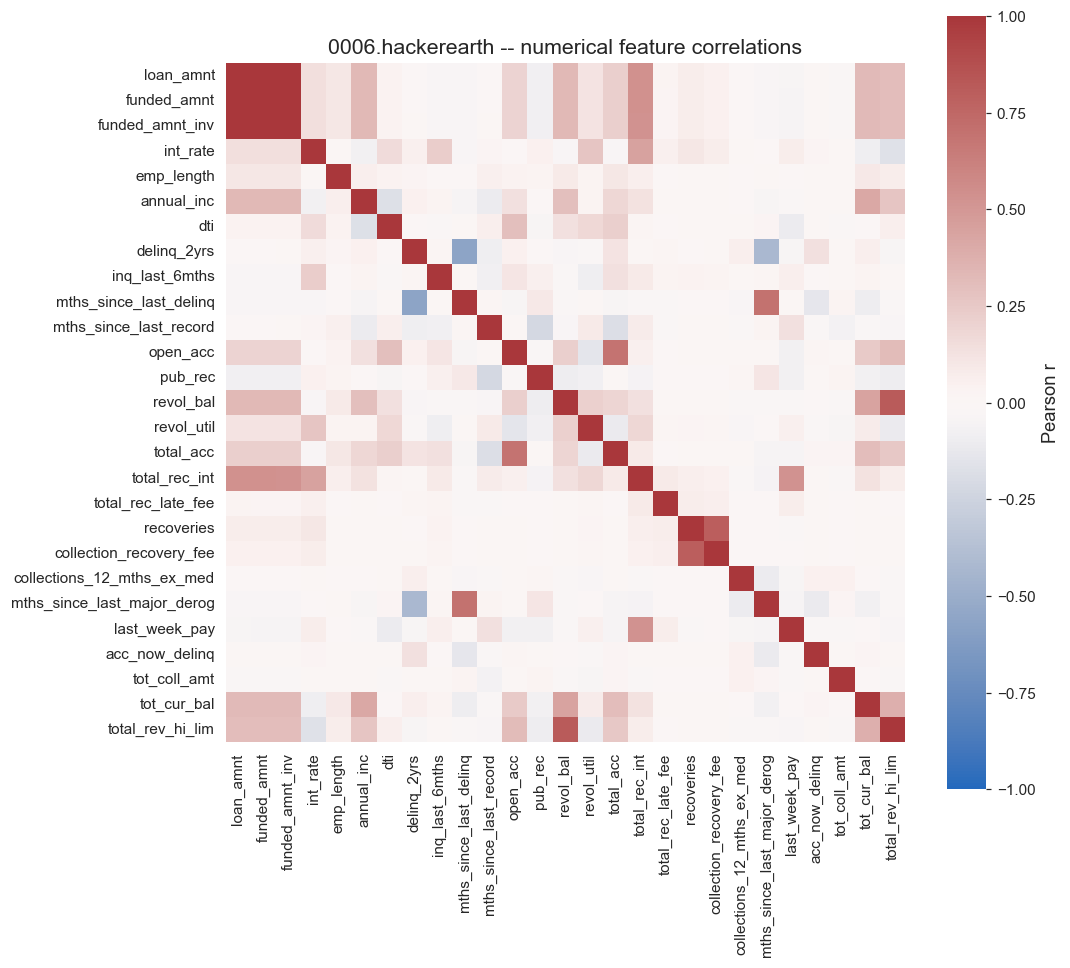

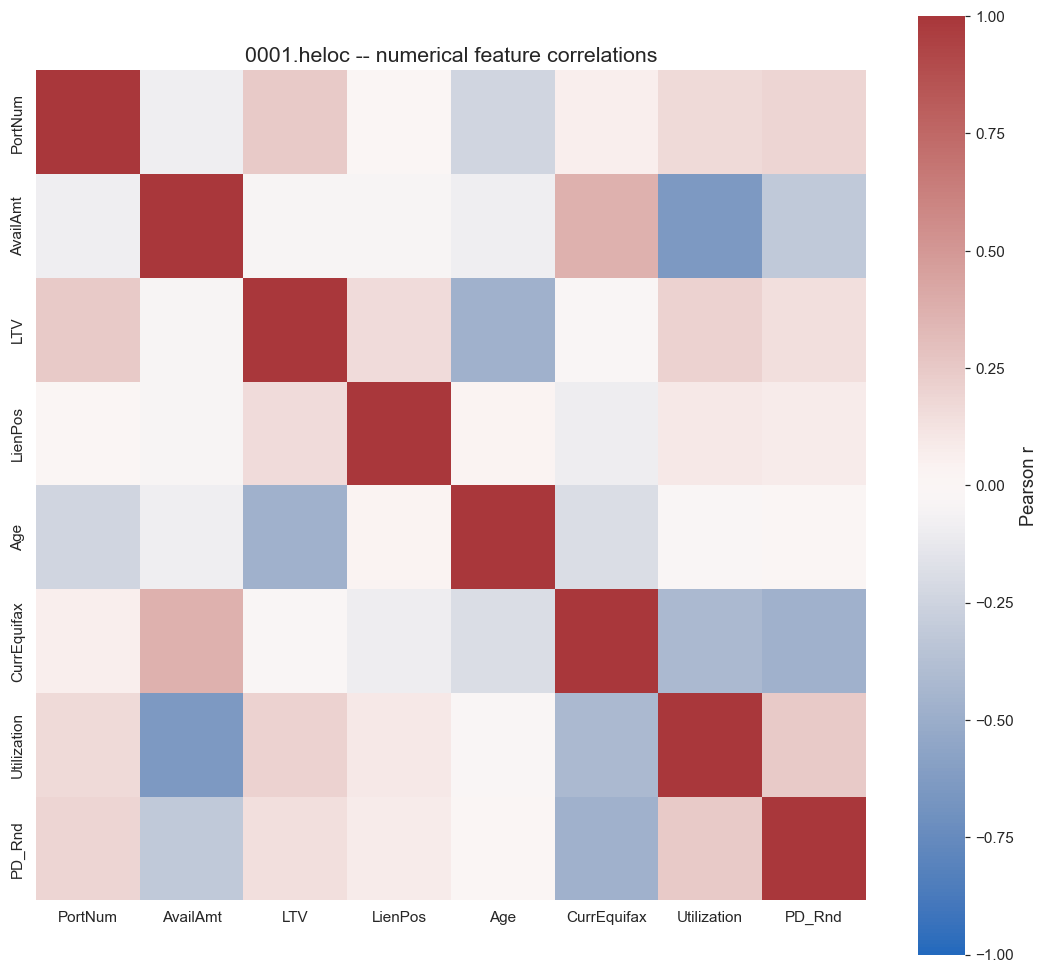

Saved feature-correlation heatmaps.


In [14]:
if not proc_pd.empty:
    sample_pd = proc_pd.sort_values('rows', ascending=False).iloc[0]['dataset']
    plot_correlation_heatmap('pd', sample_pd, out_path=FIGURES_DIR / f'pd_corr_{sample_pd}')
if not proc_lgd.empty:
    sample_lgd = proc_lgd.sort_values('rows', ascending=False).iloc[0]['dataset']
    plot_correlation_heatmap('lgd', sample_lgd, out_path=FIGURES_DIR / f'lgd_corr_{sample_lgd}')
print('Saved feature-correlation heatmaps.')

## 9. 2D PCA scatter coloured by target

Sanity check on the largest PD and LGD datasets (5 000-row sample).
For PD: are positive / negative cases linearly separable in 2D? For LGD:
does the continuous target follow a clear gradient?

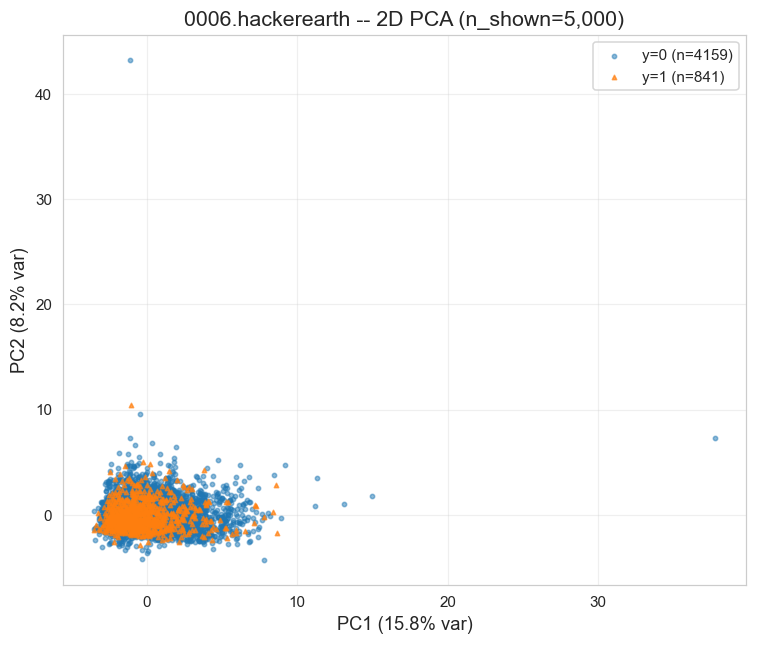

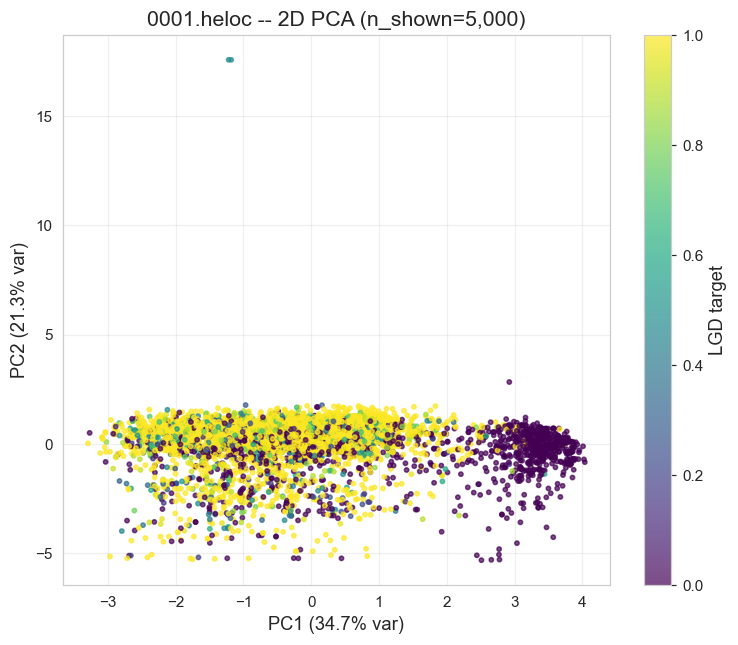

Saved PCA scatters.


In [15]:
if not proc_pd.empty:
    sample_pd = proc_pd.sort_values('rows', ascending=False).iloc[0]['dataset']
    plot_pca_2d('pd', sample_pd, out_path=FIGURES_DIR / f'pd_pca_{sample_pd}', sample=5000)
if not proc_lgd.empty:
    sample_lgd = proc_lgd.sort_values('rows', ascending=False).iloc[0]['dataset']
    plot_pca_2d('lgd', sample_lgd, out_path=FIGURES_DIR / f'lgd_pca_{sample_lgd}', sample=5000)
print('Saved PCA scatters.')